#**Examen Final Practico**

## **Nombre:** Shair Nicolas Paspuel

## **Curso:**

## **Fecha:** 17/072026



In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("real_estate_ecuador_200k.csv")
print(df.head())

                                              Titulo  Precio  Provincia  \
0  Rento Suite 75 metros sector Republica del Sal...  395.66  Pichincha   
1         “Rento departamento en sector la Carolina”  773.69  Pichincha   
2  Se Renta Amplio Departamento en el Sector de l...  616.94  Pichincha   
3  Hermoso departamento de arriendo de oportunida...  286.69  Pichincha   
4        EN RENTA DEPARTAMENTO, CONJUNTO DIVINO NIÑO  131.54  Pichincha   

                                               Lugar  Num. dormitorios  \
0  Pichincha, Av. Portugal & Av República de El S...               1.0   
1  Pichincha, Catalina de Aldaz & Av. Portugal, Q...               2.0   
2            Pichincha, Marcos Jofre, Quito, Ecuador               4.0   
3  Pichincha, De la Prensa Y del Maestro, Quito, ...               2.0   
4                     Pichincha, Turubamaba, Ecuador               3.0   

   Num. banos  Area  Num. garages  
0         2.0    65           1.0  
1         2.0    88           1.

### a. Perspectiva Financiera.
i. Precio Promedio de Alquiler (General y por Ciudad)

ii. Costo Promedio por Metro Cuadrado

iii. Rango de Precios (Min/Max/Media) por Provincia

In [32]:
print("Precio promedio general")
print(df["Precio"].mean())



Precio promedio general
732.3514613499999


In [33]:
print("Precio promedio por Ciudad")
precio_ciudad = df.groupby("Lugar")["Precio"].mean()
print("El precio por ciudad es:", precio_ciudad)

Precio promedio por Ciudad
El precio por ciudad es: Lugar
Cotopaxi, Latacunga, Cotopaxi, Ecuador                 3697.685799
Cotopaxi, Latacunga, Ecuador                            118.854358
El Oro, El Cambio, Machala, Ecuador                     124.256523
El Oro, Parroquia El Cambio, Machala                    124.458032
Esmeraldas, Av. Club del Pacífico, Tonsupa, Ecuador     508.493561
                                                          ...     
Pichincha, Whymper, Quito, Ecuador                      554.577541
Pichincha, Yaruquí, Quito, Ecuador                      450.745025
Pichincha, iñaquito                                     549.872578
Pichincha, poceano quito                                448.424332
Santa Elena, Chanduy, Ecuador                             8.968586
Name: Precio, Length: 305, dtype: float64


In [34]:

print("Rango de precios por provincia")
print(df.groupby("Provincia")["Precio"].agg(["min","max","mean"]))

Rango de precios por provincia
                 min       max         mean
Provincia                                  
Cotopaxi       94.47   4557.66  1814.528859
El Oro         98.42    155.03   124.352068
Esmeraldas    111.33    620.53   327.772537
Guayas        130.85   2816.34   614.669888
Imbabura      380.54    589.42   480.809447
Los Rios      176.04    295.08   233.589620
Manabí       5176.48   7920.44  6503.102091
Orellana      118.86    185.84   149.863608
Pichincha      80.21  11062.33   734.507750
Santa Elena     7.22     11.03     8.968586


#b. Perspectiva de Producto.
i. Distribución por Tipo de Propiedad: Conteo de registros por Tipo (Casa,
Departamento, Suite, Local Comercial, etc).

ii. Tamaño Promedio de Propiedades: Promedio (Area_m2) por Provincia.

iii. Premium por Habitación Adicional: Diferencia del precio promedio entre
propiedades de 1 habitación vs. 2 habitaciones; 2 habitaciones vs. 3, 3 vs. 4, etc.

In [35]:
df["Tipo"] = df["Titulo"].str.extract("(Casa|Departamento|Suite|Local Comerical|Terreno|)", expand=False).fillna("Otro")
print("Conteo por tipo de propiedad")
print(df["Tipo"].value_counts())


Conteo por tipo de propiedad
Tipo
                183735
Departamento     10936
Suite             2903
Casa              2426
Name: count, dtype: int64


In [36]:
print("Area Promedio por provincia")
print(df.groupby("Provincia")["Area"].mean())

Area Promedio por provincia
Provincia
Cotopaxi           72.428405
El Oro           5947.770492
Esmeraldas        110.380597
Guayas            103.337822
Imbabura          140.623116
Los Rios           88.953416
Manabí            199.649038
Orellana           27.992736
Pichincha         166.801846
Santa Elena    199727.401515
Name: Area, dtype: float64


In [63]:
premium = df.groupby("Num. dormitorios")["Precio"].mean()

print("--Premium por habitación adicional: --")
print(premium)

--Premium por habitación adicional: --
Num. dormitorios
1.0      583.885983
2.0      496.737218
3.0      591.991034
4.0     1073.325486
5.0     1307.772443
6.0     1506.978765
7.0     2735.398238
8.0      847.285812
9.0      403.899535
10.0     124.559920
11.0     138.438421
Name: Precio, dtype: float64


#c. Perspectiva Geográfica.

i. Top 5 Ciudades/Sectores Más Caros: Ranking descendente de Precio Promedio por
ubicación.

ii. Concentración de la Oferta: Conteo de propiedades por Provincia o Ciudad.

In [38]:
print("Top 5 ciudades mas caros")
print(df.groupby("Lugar")["Precio"].mean().sort_values(ascending=False).head(5))

Top 5 ciudades mas caros
Lugar
Pichincha, Avenida 10 de Agosto, Quito, Ecuador    9023.844069
Manabí, Manta, Ecuador                             6503.102091
Pichincha, La Delicia, Quito, Ecuador              4999.131409
Pichincha, Guamaní, Quito, Ecuador                 3887.606034
Cotopaxi, Latacunga, Cotopaxi, Ecuador             3697.685799
Name: Precio, dtype: float64


In [39]:
print("Concentracion de la oferta")
print(df["Provincia"].value_counts())

Concentracion de la oferta
Provincia
Pichincha      180673
Guayas          13960
Los Rios         1288
Cotopaxi          859
Esmeraldas        804
El Oro            793
Manabí            416
Orellana          413
Imbabura          398
Santa Elena       396
Name: count, dtype: int64


d. Segmentación de Mercado (Económico / Medio / Lujo):

i. Crear una nueva columna: Tipo de Inmueble.
Si precio < Q1 (Cuartil 1) -> "Económico"
Si precio > Q3 (Cuartil 3) -> "Lujo"
Resto -> "Medio"


In [40]:
q1 = df["Precio"].quantile(0.25)
q2 = df["Precio"].quantile(0.75)

df["Tipo de Inmueble"] = df["Precio"].apply(lambda x: "Economico" if x < q1 else("Lujo" if x > q2 else "Medio"))

print("Segmentacion")
print(df["Tipo de Inmueble"].value_counts())

Segmentacion
Tipo de Inmueble
Medio        100001
Lujo          50000
Economico     49999
Name: count, dtype: int64


#e. Dashboard
i. Total de propiedades

ii. Gráfico de barras de Precio promedio de alquiler (General y por Ciudad)

iii. Gráfico de dispersión de la relación entre Área y Precio

iv. Gráfico de pastel de conteo de registros por Tipo (Casa, Departamento, Suite, Local
Comercial).

v. Gráfico de Premium por Habitación Adicional

Total de propiedades


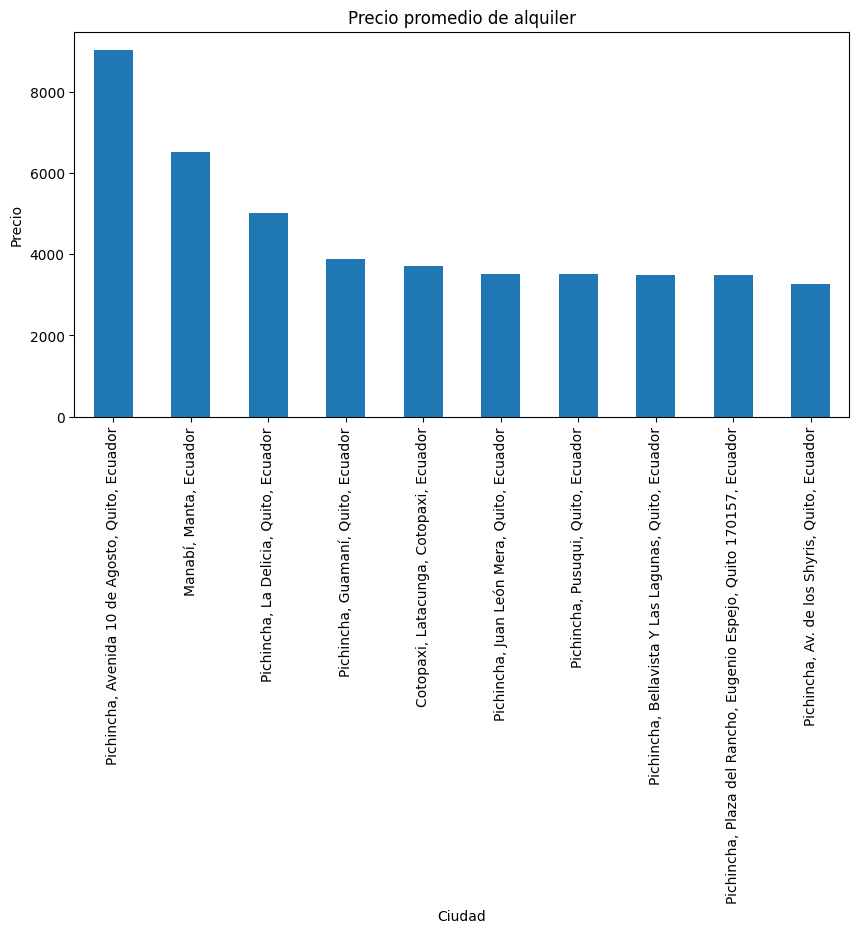

In [42]:
print("Total de propiedades")

plt.figure(figsize=(10,5))
precio_ciudad.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Precio promedio de alquiler")
plt.xlabel("Ciudad")
plt.ylabel("Precio")
plt.show()

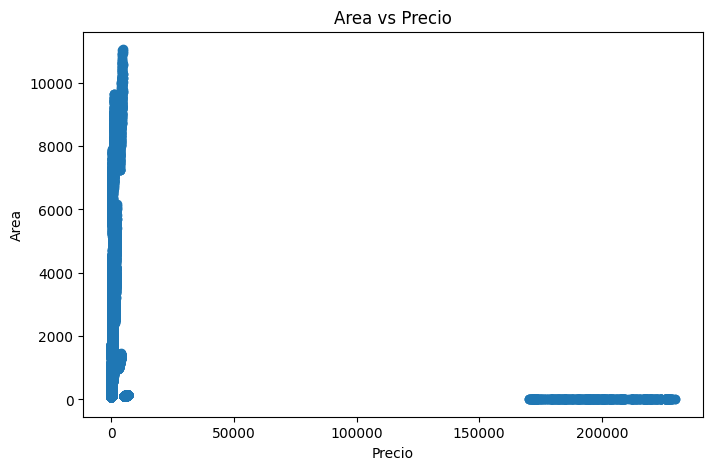

In [44]:
plt.figure(figsize=(8,5))
plt.scatter(df["Area"], df["Precio"])
plt.title("Area vs Precio")
plt.ylabel("Area")
plt.xlabel("Precio")
plt.show()

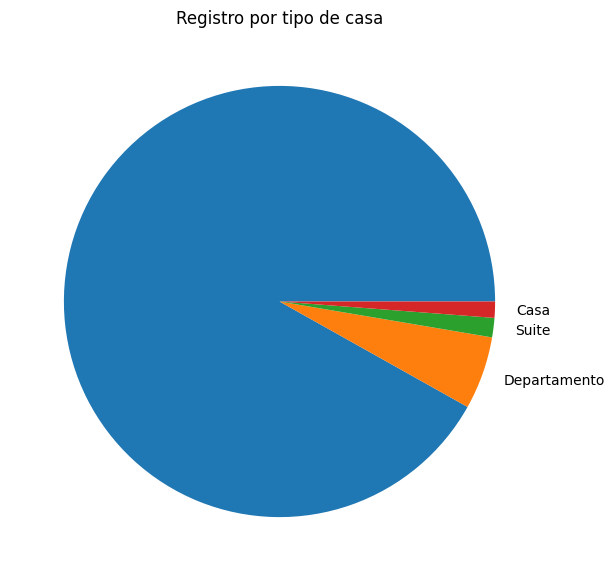

In [47]:
plt.figure(figsize=(7,7))
df["Tipo"].value_counts(). plot(kind = "pie")
plt.title("Registro por tipo de casa")
plt.ylabel("")
plt.show()


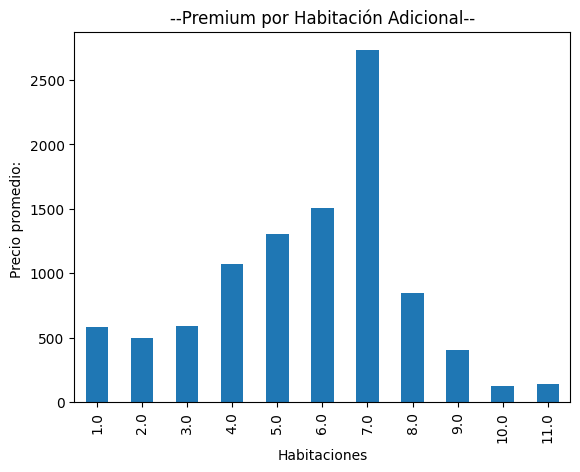

In [65]:
premium.plot(kind = "bar")
plt.title("--Premium por Habitación Adicional--")
plt.xlabel("Habitaciones")
plt.ylabel("Precio promedio: ")
plt.show()